In [1]:
# ==========================================
# IMPACTSENSE: WEEK 1 - DATA EXPLORATION
# ==========================================

In [2]:
# Cell 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
# Cell 2: Load the dataset
# Assuming your notebook is in a 'notebooks' folder and data is in a 'data' folder
df = pd.read_csv('../../data/earthquake_data.csv')

# Look at the shape (number of rows and columns) and the first 5 rows
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (782, 19)


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN


In [8]:
# Cell 3: Clean the data
# 1. Remove duplicate rows
df.drop_duplicates(inplace=True)

# 2. Drop rows where critical features are missing
df.dropna(subset=['magnitude', 'depth', 'latitude', 'longitude'], inplace=True)

print("Data cleaned! New shape:", df.shape)

Data cleaned! New shape: (782, 19)


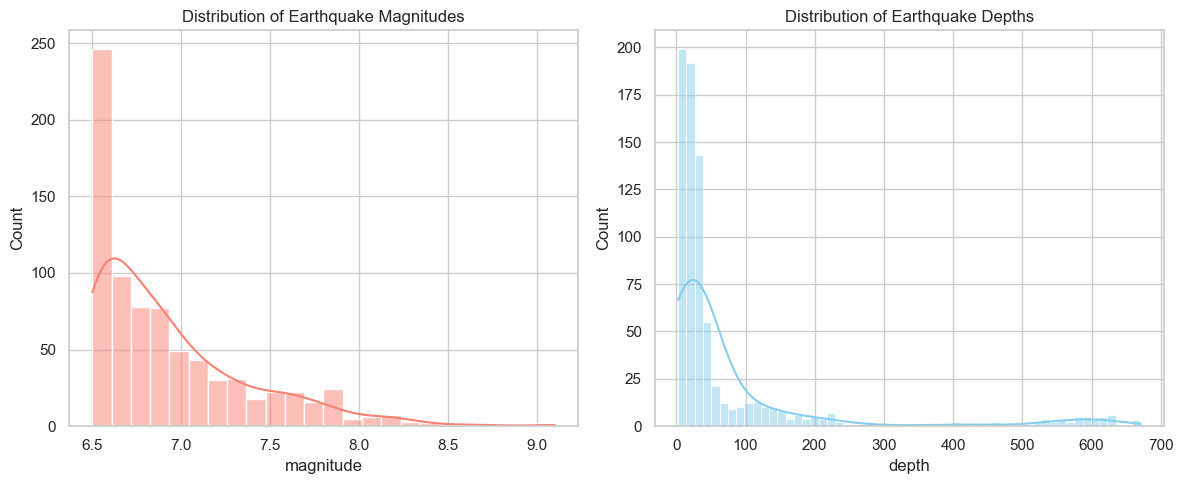

In [9]:
# Cell 4: Visualize depth and magnitude
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot Magnitude
sns.histplot(df['magnitude'], kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribution of Earthquake Magnitudes')

# Plot Depth
sns.histplot(df['depth'], kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Earthquake Depths')

plt.tight_layout()
plt.show()

In [10]:
# Cell 5: Map earthquake locations
fig_map = px.scatter_geo(df, 
                         lat='latitude', 
                         lon='longitude', 
                         color='magnitude',
                         size='magnitude',
                         opacity=0.6,
                         projection="natural earth",
                         title='Earthquake Geospatial Distribution')
fig_map.show()

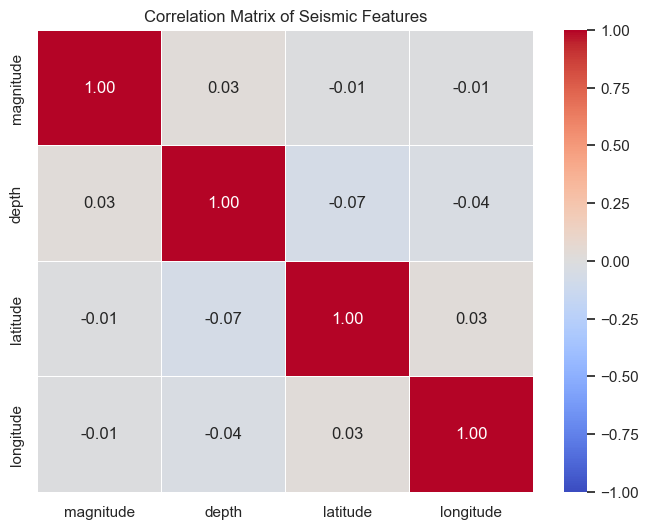

In [11]:
# Cell: Correlation Matrix of Seismic Features
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the numeric columns relevant to our architecture
numeric_features = ['magnitude', 'depth', 'latitude', 'longitude']
corr_matrix = df[numeric_features].corr()

# 2. Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# 3. Draw the heatmap with seaborn
# 'annot=True' puts the actual numbers on the squares
# 'cmap=coolwarm' makes strong positive correlations red and strong negative ones blue
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            fmt=".2f", 
            linewidths=0.5)

plt.title('Correlation Matrix of Seismic Features')
plt.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_6096\1256793330.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,


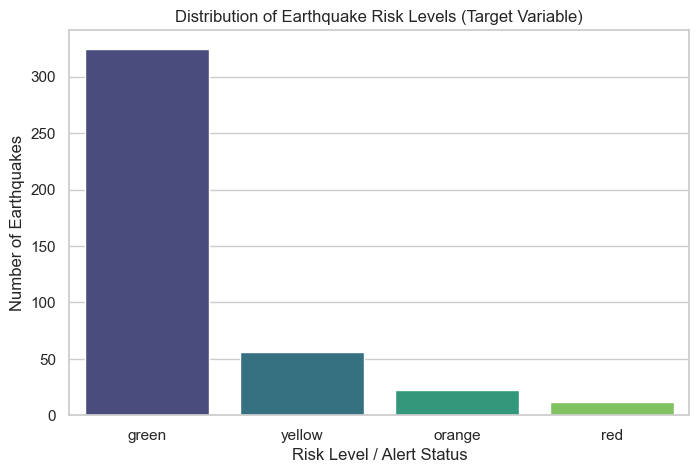

Exact counts per category:
 alert
green     325
yellow     56
orange     22
red        12
Name: count, dtype: int64


In [12]:
# Cell: Target Variable Analysis (Checking for Class Imbalance)
import seaborn as sns
import matplotlib.pyplot as plt

# Define your target column (the thing you want to predict)
# Change 'alert' to your actual target column name if it's different (e.g., 'damage_grade')
target_col = 'alert' 

if target_col in df.columns:
    plt.figure(figsize=(8, 5))
    
    # Create a bar chart showing the count of each category
    sns.countplot(data=df, 
                  x=target_col, 
                  order=df[target_col].value_counts().index, 
                  palette='viridis')
    
    plt.title('Distribution of Earthquake Risk Levels (Target Variable)')
    plt.ylabel('Number of Earthquakes')
    plt.xlabel('Risk Level / Alert Status')
    plt.show()
    
    
    # Print the exact numbers
    print("Exact counts per category:\n", df[target_col].value_counts())
else:
    print(f"Column '{target_col}' not found. If predicting magnitude instead of categories, you have already visualized it above!")